# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [14]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [15]:
#Bibliotecas
import pandas as pd
import numpy as np
from google.colab import files
import gdown
import matplotlib.pyplot as plt
import random
import seaborn as sns

# **Importando datasets temáticos classificados e homologados**

In [16]:
# baixando datasets para o collab
import gdown

file_class_aborto = "19uIbpGTjdcPtmXDvMW3ljlTIoBtQL7Nm" #Convergencias aborto
file_class_cloroquina = "1B0vbasDyKIKpX8Cl-uqL6AhDagEHtqT0" #convergencias cloroquina
file_class_contas_suspensas = "1xHMG0odNlWABwmA18ACK-nOedwKmSsDN" #convergencias contas suspensas
file_class_mandetta = "1W1uO_6LfgmWQRkGQCteFQNWDA5kUQ_RP" #convergencias mandetta

url_1 = f"https://drive.google.com/uc?id={file_class_aborto}"
url_2 = f"https://drive.google.com/uc?id={file_class_cloroquina}"
url_3 = f"https://drive.google.com/uc?id={file_class_contas_suspensas}"
url_4 = f"https://drive.google.com/uc?id={file_class_mandetta}"


gdown.download(url_1, "aborto_homologado.csv", quiet=False)
gdown.download(url_2, "cloroquina_homologado.csv", quiet=False)
gdown.download(url_3, "contas_suspensas_homologado.csv", quiet=False)
gdown.download(url_4, "mandetta_homologado.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=19uIbpGTjdcPtmXDvMW3ljlTIoBtQL7Nm
To: /content/aborto_homologado.csv
100%|██████████| 106k/106k [00:00<00:00, 37.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1B0vbasDyKIKpX8Cl-uqL6AhDagEHtqT0
To: /content/cloroquina_homologado.csv
100%|██████████| 125k/125k [00:00<00:00, 65.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1xHMG0odNlWABwmA18ACK-nOedwKmSsDN
To: /content/contas_suspensas_homologado.csv
100%|██████████| 83.9k/83.9k [00:00<00:00, 40.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1W1uO_6LfgmWQRkGQCteFQNWDA5kUQ_RP
To: /content/mandetta_homologado.csv
100%|██████████| 122k/122k [00:00<00:00, 65.8MB/s]


'mandetta_homologado.csv'

In [17]:
#Carregando e processando os datasets tematicos
df_aborto = pd.read_csv ("aborto_homologado.csv")
df_aborto['Conflict'] = df_aborto['Conflict'].astype(int) #convertendo valores para inteiros
df_cloroquina = pd.read_csv ("cloroquina_homologado.csv")
df_cloroquina['Conflict'] = df_cloroquina['Conflict'].astype(int) #convertendo valores para inteiros
df_contas_suspensas = pd.read_csv ("contas_suspensas_homologado.csv")
df_contas_suspensas['Conflict'] = df_contas_suspensas['Conflict'].astype(int) #convertendo valores para inteiros
df_mandetta = pd.read_csv ("mandetta_homologado.csv")
df_mandetta['Conflict'] = df_mandetta['Conflict'].astype(int) #convertendo valores para inteiros

#**Análise exploratória dos dataset temáticos:**

In [18]:
#NUMERO TOTAL DE INSTANCIAS HOMOLOGADAS
print("NUMERO DE INSTANCIAS HOMOLOGADAS:")
print("Aborto: ", df_aborto.shape)
print("Cloroquina: ", df_cloroquina.shape)
print("Contas suspensas: ", df_contas_suspensas.shape)
print("Mandetta: ", df_mandetta.shape)
print("Total: ", df_aborto.shape[0] + df_cloroquina.shape[0] + df_contas_suspensas.shape[0] + df_mandetta.shape[0])

NUMERO DE INSTANCIAS HOMOLOGADAS:
Aborto:  (435, 4)
Cloroquina:  (390, 4)
Contas suspensas:  (280, 4)
Mandetta:  (405, 4)
Total:  1510


In [19]:
#CLASSIFICAÇÕES POR CLASSES
print("CLASSIFICAÇÕES POR CLASSES:")
print("Aborto:")
print("Conflito:", df_aborto[df_aborto['Conflict'] == 1].shape[0])
print("Não conflito:", df_aborto[df_aborto['Conflict'] == 0].shape[0])
print("indeterminado:", df_aborto[df_aborto['Conflict'] == -1].shape[0])
print()
print("Cloroquina:")
print("Conflito:", df_cloroquina[df_cloroquina['Conflict'] == 1].shape[0])
print("Não conflito:", df_cloroquina[df_cloroquina['Conflict'] == 0].shape[0])
print("indeterminado:", df_cloroquina[df_cloroquina['Conflict'] == -1].shape[0])
print()
print("Contas suspensas:")
print("Conflito:", df_contas_suspensas[df_contas_suspensas['Conflict'] == 1].shape[0])
print("Não conflito:", df_contas_suspensas[df_contas_suspensas['Conflict'] == 0].shape[0])
print("indeterminado:", df_contas_suspensas[df_contas_suspensas['Conflict'] == -1].shape[0])
print()
print("Mandetta:")
print("Conflito:", df_mandetta[df_mandetta['Conflict'] == 1].shape[0])
print("Não conflito:", df_mandetta[df_mandetta['Conflict'] == 0].shape[0])
print("indeterminado:", df_mandetta[df_mandetta['Conflict'] == -1].shape[0])


CLASSIFICAÇÕES POR CLASSES:
Aborto:
Conflito: 115
Não conflito: 299
indeterminado: 21

Cloroquina:
Conflito: 117
Não conflito: 267
indeterminado: 6

Contas suspensas:
Conflito: 41
Não conflito: 239
indeterminado: 0

Mandetta:
Conflito: 62
Não conflito: 343
indeterminado: 0


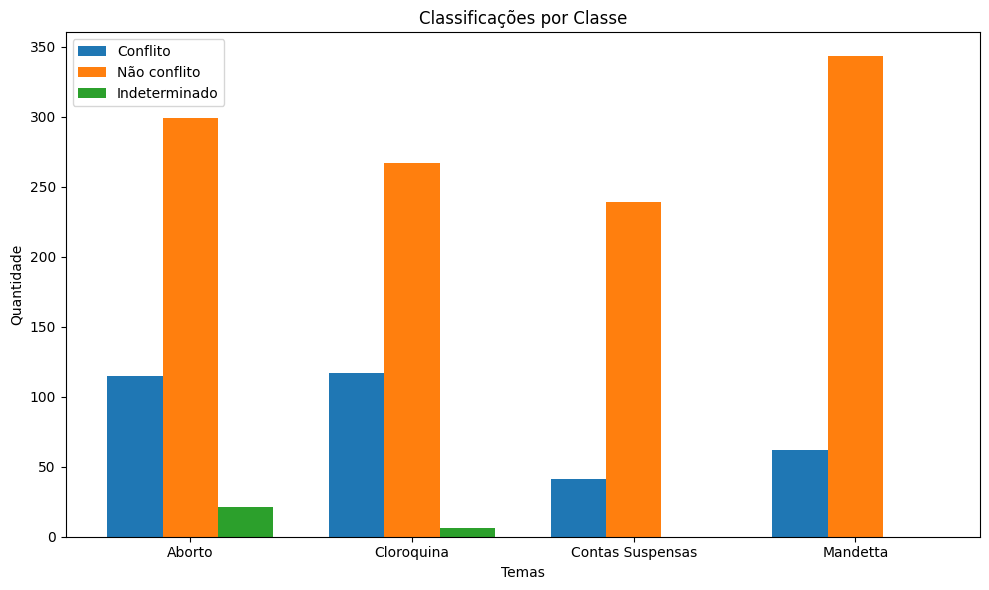

In [20]:
#GRAFICOS
#classificações por classes

#Organizando os dados
temas = ["Aborto", "Cloroquina", "Contas Suspensas", "Mandetta"]

conflito = [
    df_aborto[df_aborto['Conflict'] == 1].shape[0],
    df_cloroquina[df_cloroquina['Conflict'] == 1].shape[0],
    df_contas_suspensas[df_contas_suspensas['Conflict'] == 1].shape[0],
    df_mandetta[df_mandetta['Conflict'] == 1].shape[0]
]

nao_conflito = [
    df_aborto[df_aborto['Conflict'] == 0].shape[0],
    df_cloroquina[df_cloroquina['Conflict'] == 0].shape[0],
    df_contas_suspensas[df_contas_suspensas['Conflict'] == 0].shape[0],
    df_mandetta[df_mandetta['Conflict'] == 0].shape[0]
]

indeterminado = [
    df_aborto[df_aborto['Conflict'] == -1].shape[0],
    df_cloroquina[df_cloroquina['Conflict'] == -1].shape[0],
    df_contas_suspensas[df_contas_suspensas['Conflict'] == -1].shape[0],
    df_mandetta[df_mandetta['Conflict'] == -1].shape[0]
]

#posicionando barras

x = np.arange(len(temas)) #cria vetor [0,1,2,..,(len(temas))]

largura = 0.25

#desenhando grafico

plt.figure(figsize=(10, 6))

plt.bar(x - largura, conflito, width=largura, label="Conflito")
plt.bar(x, nao_conflito, width=largura, label="Não conflito")
plt.bar(x + largura, indeterminado, width=largura, label="Indeterminado")


plt.xticks(x, temas)

plt.title("Classificações por Classe")
plt.xlabel("Temas")
plt.ylabel("Quantidade")

plt.legend() #cria a caixinha de legenda

plt.tight_layout() #ajusta resolução para não cortar texto

plt.show()

#**Dataset final**

In [21]:
#CONCATENANDO DATASETS TEMÁTICOS
df_final = pd.concat([df_aborto, df_cloroquina, df_contas_suspensas, df_mandetta], ignore_index=True, axis = 0)
df_final.shape

(1510, 4)

In [22]:
df_final

,tweet_1,tweet_2,Class,Conflict
0,#AbortoNao crianças em internatos não é conseq...,0 ARGUMENTOS pra esse povo q apoia aborto #Abo...,0,0
1,#AbortoNao Não vamos deixar o STF legislar ma...,#AbortoSim o feto não é considerado humano an...,0,1
2,#AbortoNao é um crime o pautar um assunto tão...,Quem comete aborto mata um ser inocente que nã...,0,0
3,Tentar reduzir o aborto a uma questão de saúde...,Todos os homens são contra o aborto até o dia ...,0,1
4,"#AbortoNao ou #AbortoSIM Não tenho útero, ent...",O Brasil é cristão e conservador! #AbortoNao,0,0
...,...,...,...,...
1505,Bolsonaro tem muita dificuldade de achar subst...,Principalmente porque o principl requisito que...,2,0
1506,Mandetta já sabia da Pandemia no Carnaval. Ao ...,#ForaMandettaUrgente ATITUDE presidente,2,0
1507,Planalto investiga assessores de Mandetta e pr...,"Demorou, caça as bruxas...beginning...o pior m...",2,0
1508,Mandetta e sua política de isolamento estão lo...,Cansei de falar isso!,2,0


In [23]:
#ANALISE EXPLORATÓRIA - DATASET FINAL
print("CLASSIFICAÇÕES POR CLASSES:")
print("conflito:", df_final[df_final['Conflict'] == 1].shape[0])
print("não conflito:", df_final[df_final['Conflict'] == 0].shape[0])
print("indeterminado:", df_final[df_final['Conflict'] == -1].shape[0])

CLASSIFICAÇÕES POR CLASSES:
conflito: 335
não conflito: 1148
indeterminado: 27


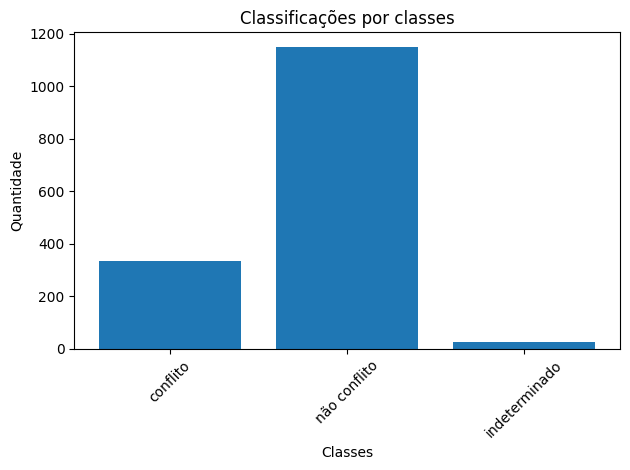

In [24]:
#GRAFICOS
#classificações por classes (conflito e não conflito)
conflitos = df_final[df_final['Conflict'] == 1].shape[0]
nao_conflitos = df_final[df_final['Conflict'] == 0].shape[0]
indeterminados = df_final[df_final['Conflict'] == -1].shape[0]

labels = ["conflito","não conflito", "indeterminado"]
values = [conflitos, nao_conflitos, indeterminados]
plt.figure()
plt.bar(labels, values)
plt.title("Classificações por classes")
plt.xlabel("Classes")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#classificações por estrutura de tweet (reply, quote, original)

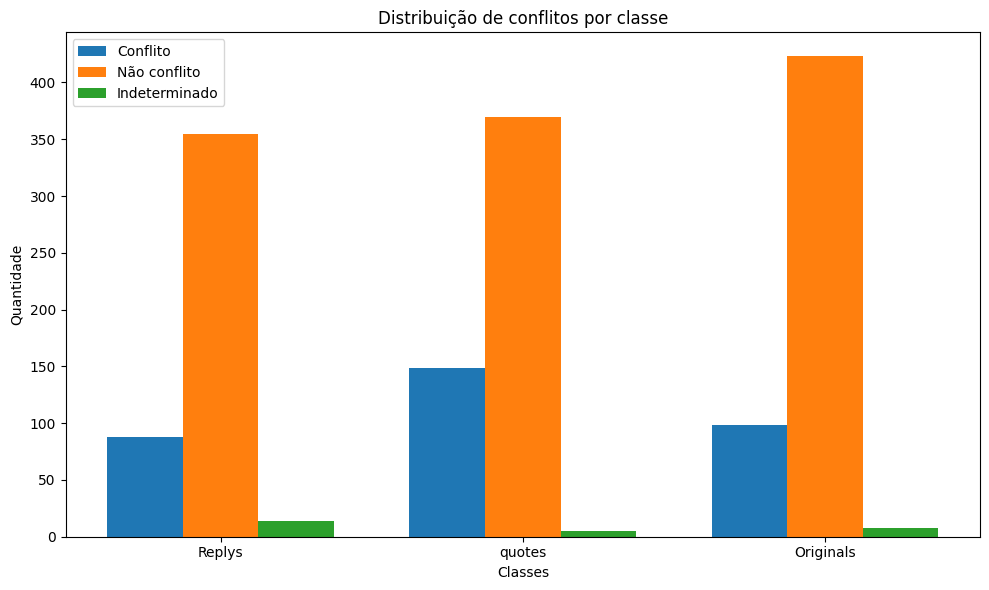

In [25]:
#Distribuição de conflitos por classes

#Separando as classes
reply = df_final[df_final['Class'] == 0]
quote = df_final[df_final['Class'] == 1]
original = df_final[df_final['Class'] == 2]

#Registando as contagens de classificações por estruturas
classes = ['Replys', 'quotes', 'Originals']

conflitos = [
    reply[reply['Conflict'] == 1].shape[0],
    quote[quote['Conflict'] == 1].shape[0],
    original[original['Conflict'] == 1].shape[0]
]

nao_conflitos = [
    reply[reply['Conflict'] == 0].shape[0],
    quote[quote['Conflict'] == 0].shape[0],
    original[original['Conflict'] == 0].shape[0]
]

indeterminados = [
    reply[reply['Conflict'] == -1].shape[0],
    quote[quote['Conflict'] == -1].shape[0],
    original[original['Conflict'] == -1].shape[0]
]



# Posição das barras

x = np.arange(len(classes))

largura = 0.25

#desenhando o grafico

plt.figure(figsize=(10,6))

plt.bar(x - largura, conflitos,
        width=largura,
        label='Conflito')

plt.bar(x, nao_conflitos,
        width=largura,
        label='Não conflito')

plt.bar(x + largura, indeterminados,
        width=largura,
        label='Indeterminado')

plt.xticks(x, classes)

plt.xlabel("Classes")
plt.ylabel("Quantidade")

plt.title("Distribuição de conflitos por classe")

plt.legend()

plt.tight_layout()

plt.show()

In [26]:
df_final.to_csv("dataset_conflitos.csv", index=False, encoding="utf-8")
files.download("dataset_conflitos.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>